# XAIKitTest Experiment Simulation Tutorial

A compact end-to-end workflow for planning an XAI user study, training an AI model, generating explanations, previewing participant trials, and running a cognitive simulation.

## Workflow Outline

1. Create the workflow object
2. Define IVs, CVs, user task, and DVs
3. Prepare the dataset
4. Generate participant trials
5. Train and evaluate the AI model
6. Generate and visualize explanations
7. Preview one participant's trials
8. Configure the cognitive model
9. Run and save simulation results


## 0. Setup


In [20]:
from pathlib import Path
import sys

import pandas as pd

repo_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "api.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import XAIKitTest


## 1. Create Workflow

Create one object to hold design, data, model, explanations, trials, and simulation outputs.


In [21]:
xaikitTest = XAIKitTest(
    project_name="xai_comparison_user_study",
    output_dir=".",
)


Good afternoon. XAIKitTest is ready for 'xai_comparison_user_study'.
Start by choosing the XAI experiment you want to run. Call `xaikitTest.guide_design()` for a concise design guide.


## 2. Design Experiment

Define what changes across conditions, what metadata is tracked, what task users perform, and what outcomes are measured.


In [22]:
xaikitTest.guide_design()


Design guide
Goal: decide what XAI methods you want to test and how the study compares them.
IV: what you manipulate, e.g. `xai_method = ['shap', 'lime', 'none']`.
CV: trial/participant metadata you control or record, e.g. age group, gender, user_task.
DV: what you measure, e.g. `forward_accuracy`.
User task: what participants/cognitive agents do, e.g. `forward_simulation` means predict the AI output from the instance and explanation.
Typical call: add IVs, add CVs, add `user_task`, add DVs, then `validate(stage='design')`.


In [23]:
xaikitTest.add_iv(
    "xai_method",
    "between",
    ["shap", "lime", "lrp", "none"],
)

xaikitTest.add_iv(
    "tested_w_xai",
    "within",
    [True, False],
    randomization="trial",
)

xaikitTest.add_cv("age_group", ["young", "adult", "senior"])
xaikitTest.add_cv("gender", ["male", "female"])
xaikitTest.add_cv("user_task", ["forward_simulation"])

xaikitTest.add_dv("forward_accuracy", ["continuous"])

xaikitTest.validate(stage="design", show=True)


XAIKit validation: design

Normalized:
  IVs:
    xai_method: shap, lime, lrp, none
    tested_w_xai: True, False
  Semantic CVs:
    user_task: forward_simulation
  DVs: forward_accuracy
  CVs: age_group, gender, user_task
  Context:
    dataset_id: not set
    model_name: not set
    model_source: not set
    cognitive_model_id: placeholder
    tasks: forward_simulation
    xai_methods: shap, lime, lrp, none
    xai_types: not set
    xai_faithfulness: not set
    dvs: forward_accuracy

## 3. Prepare Dataset

Load a dataset and keep one stable split for training, trials, explanations, and display.


In [24]:
data = xaikitTest.prepare_dataset(
    "wine_quality",
    feature_cols=["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "pH"],
    num_features=5,
    rank_features_by_target=True,
    test_size=0.2,
    random_state=42,
)

# Alternative example:
# data = xaikitTest.prepare_dataset("forest_cover", random_state=42)


Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]


## 4. Generate Trials

Create participant assignments and trial rows from the stored design and test-instance pool.


In [25]:
xaikitTest.validate(stage="trial_generation", show=True)

trial_result = xaikitTest.generate_trials(
    participants_per_between_condition=25,
    trials_per_participant=10,
    trial_randomization_strategy="balanced",
    output_dir="experiment_output",
    seed=42,
    preview_rows=5,
)


Counterbalancing strategy: complete_counterbalancing
Participant assignments: 100 total
Instance pool rows: 300
Trial rows: 1000
Exported trial artifacts:
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json

Previewing first 5 trial rows:
{'participantId': 1, 'trialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': False, 'dataId': 'wine_quality', 'instanceId': '1329'}
{'participantId': 1, 'trialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '535'}
{'participantId': 1, 'trialId': 3, 'block': 1, 'trialWithinBlock': 3, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '1070'}
{'participantId': 1, 'trialId': 4, 'block': 1, 'trialWithinBlock': 4, 'within

## 5. Train AI Model

Call `xaikitTest.guide("training")` for the training arguments. Supported model types include `mlp`, `xgboost`, and `sim2real`.


In [26]:
xaikitTest.guide("training")


Model guide
Goal: train the AI model that later provides predictions and explanations.
Supported model types: `mlp`, `xgboost`, `sim2real`.
Key args: `model_type`, target metric/score, epoch limits, batch size.


In [37]:
model = xaikitTest.train_AI_model(
    model_type="mlp",
    target_metric="accuracy",
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)

training_summary = xaikitTest.training_summary_table()
training_history = xaikitTest.training_history_table()

display(training_summary)
# display(training_history)


,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.900704,240,100,True,0.9,0.900704,mlp,wine_quality


## 6. Evaluate AI Model

Review scalar metrics and the held-out test confusion matrix.


Test accuracy: 0.8969


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
train,0.902267,0.711016,0.728972,0.448276,0.555160,0.922999,0.655725,0.823530,0.711016,0.750132,0.892361,0.902267,0.892054
test,0.896875,0.685039,0.708333,0.395349,0.507463,0.834859,0.623943,0.810248,0.685039,0.724936,0.884773,0.896875,0.883963


,predicted_0,predicted_1
actual_0,270,7
actual_1,26,17


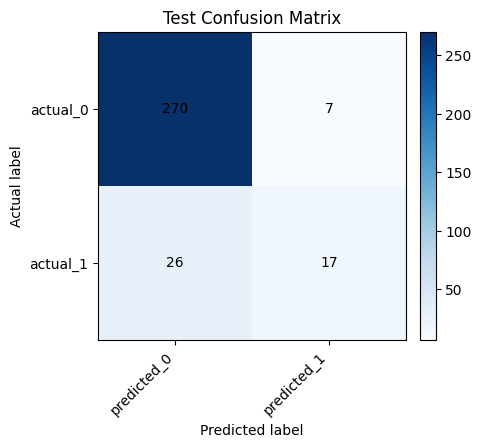

In [28]:
metrics = xaikitTest.evaluate(split="both", positive_label=1, threshold=0.5)
metrics_table = xaikitTest.metrics_table()

test_accuracy = xaikitTest.test_accuracy()
test_confusion_matrix = xaikitTest.confusion_matrix_table(split="test")

print(f"Test accuracy: {test_accuracy:.4f}")
display(metrics_table)
display(test_confusion_matrix)

ax = xaikitTest.plot_confusion_matrix(split="test")


## 7. Generate Explanations

Generate explanation tables using the XAI methods already stored in the design.


In [29]:
xaikitTest.guide("xai")


Explanation guide
Goal: generate XAI tables for the methods stored in your design.
Default methods come from `xai_method`; default model name comes from training.
Key args: `target`, `output_dir`, optional method kwargs such as SHAP background size or LIME samples.


In [30]:
combined_path, combined_df = xaikitTest.explanations(
    output_dir="generated_explanation",
    target=1,
    method_kwargs={
        "shap": {"n_background_samples": 30},
        "shap_kernel": {"n_background_samples": 30},
        "lime": {"num_samples": 1000},
    },
)

print(f"Combined explanation path: {combined_path}")
display(combined_df.head())


Using stored XAI methods from the design: ['shap', 'lime', 'lrp', 'none']
Using stored model name for explanation files: 'mlp'
Generating explanations for 300 test instances.

Generating explanations for xai method: shap


100%|██████████| 300/300 [00:00<00:00, 566.71it/s]


  Saved: generated_explanation/shap_mlp_wine_quality.csv shape=(300, 12)

Generating explanations for xai method: lime
  Saved: generated_explanation/lime_mlp_wine_quality.csv shape=(300, 12)

Generating explanations for xai method: lrp
  Saved: generated_explanation/lrp_mlp_wine_quality.csv shape=(300, 12)
Skipping explanation generation for xai method: none

Combined explanation CSV: generated_explanation/de_mlp_wine_quality.csv shape=(900, 12)
Combined explanation path: generated_explanation/de_mlp_wine_quality.csv


,dataId,modelName,expMethod,instanceId,pred,i_max,a0_i,a1_i,a2_i,a3_i,a4_i,intercept
0,wine_quality,mlp,shap,434,0,0.123286,-1.000000,0.152420,0.248496,-0.333194,0.145184,0.147901
1,wine_quality,mlp,shap,213,0,0.074230,-0.517383,-0.188860,-1.000000,-0.252767,-0.033423,0.147901
2,wine_quality,mlp,shap,1447,0,0.121182,-1.000000,-0.225120,0.186793,-0.016606,-0.118618,0.147901
3,wine_quality,mlp,shap,231,0,0.061538,-0.968368,-0.058109,-1.000000,-0.131671,-0.212298,0.147901
4,wine_quality,mlp,shap,763,0,0.065041,-0.940402,-0.324283,-1.000000,0.018333,-0.027606,0.147901


### 7.1 Visualize One Explanation

Use `visualization="importance"` for support toward the predicted class, or `visualization="influence"` for signed attribution.


(<Figure size 1050x435 with 5 Axes>,
 array([<Axes: title={'center': 'Attribute'}>,
        <Axes: title={'center': 'Value'}>, <Axes: >,
        <Axes: title={'center': 'Importance'}>, <Axes: >], dtype=object))

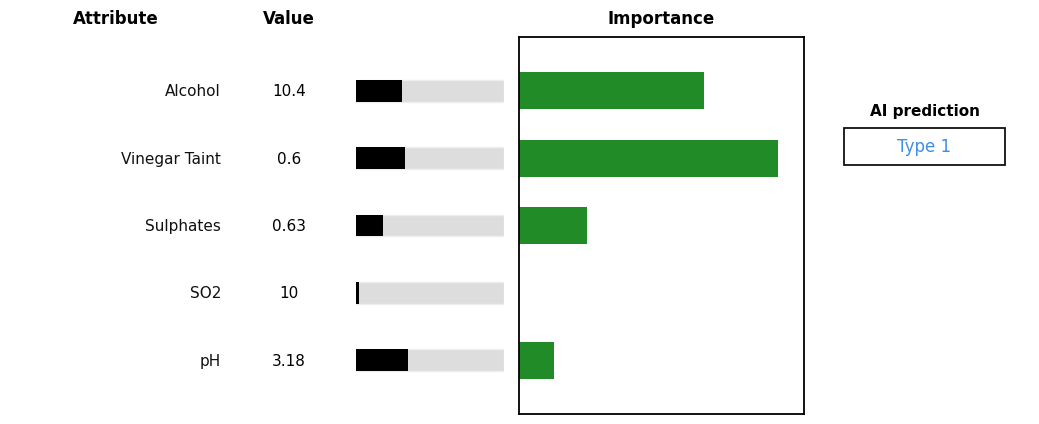

In [31]:
xaikitTest.plot_explanation(
    visualization="importance",
    method="shap",
    instance_id=int(xaikitTest.data.test_instance_ids[10]),
    top_n=5,
    class_labels=["Type 1", "Type 2"],
)


## 8. Preview Participant Trials

Browse one participant's instances one by one. Trials with XAI show the explanation; trials without XAI show the raw instance values.


ipywidgets unavailable. Showing HTML Back/Next preview.


participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction
1,1,1329,shap,False,0
participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction
1,2,535,shap,True,0
participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction
1,3,1070,shap,True,1
participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction
1,4,984,shap,False,0
participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction
1,5,779,shap,False,0
participantId,trialId,instanceId,xai_method,tested_w_xai,ai_prediction

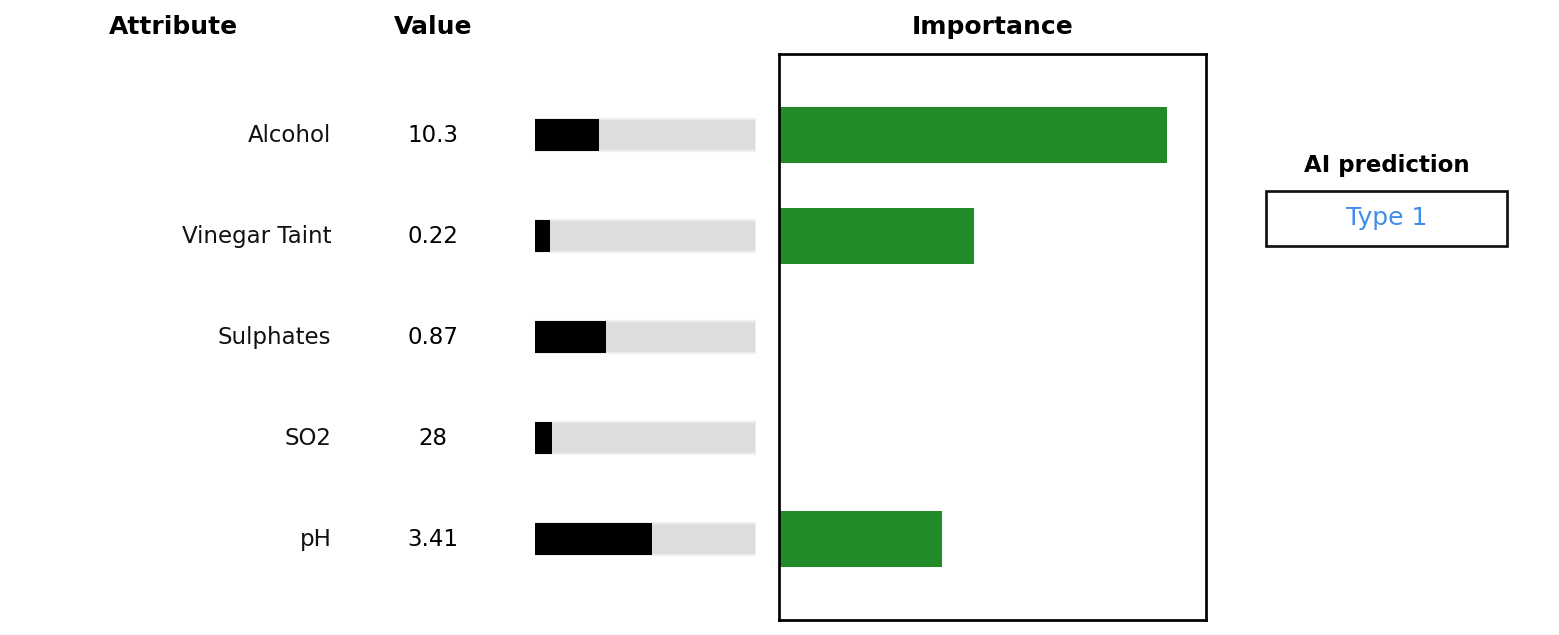
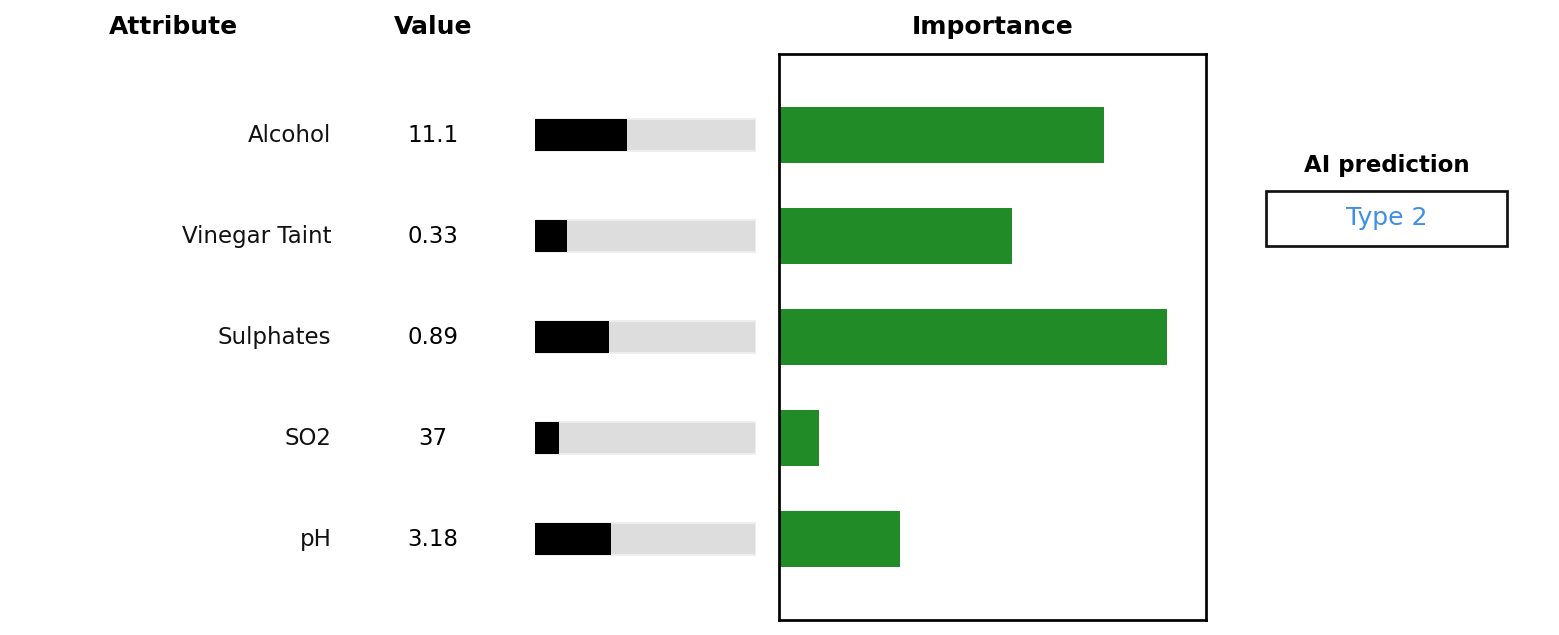
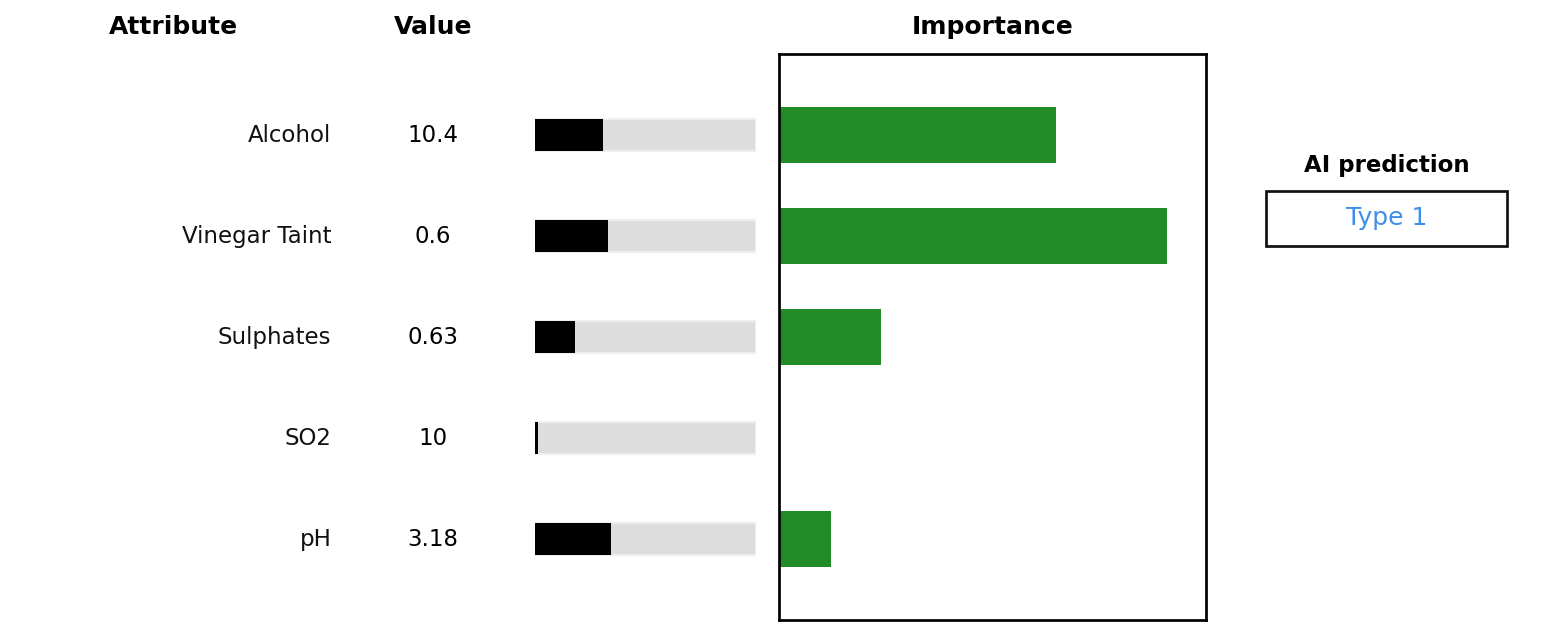
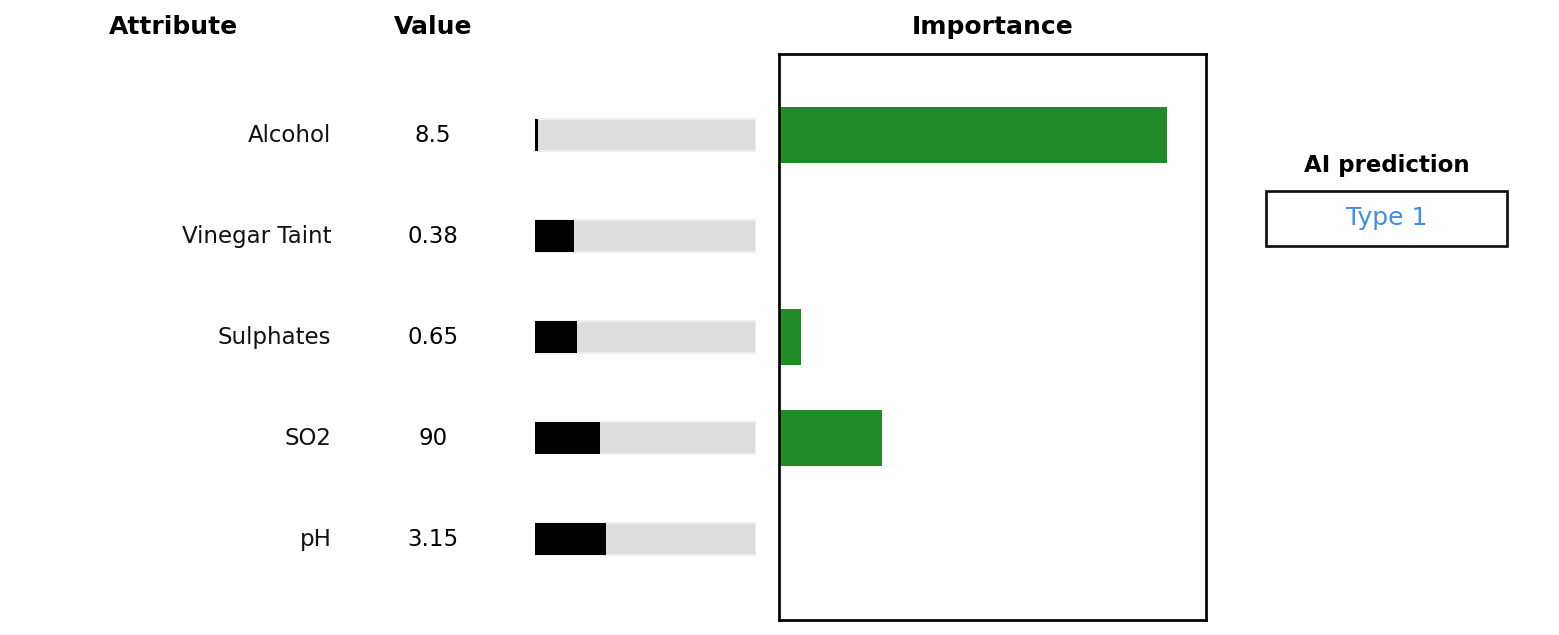
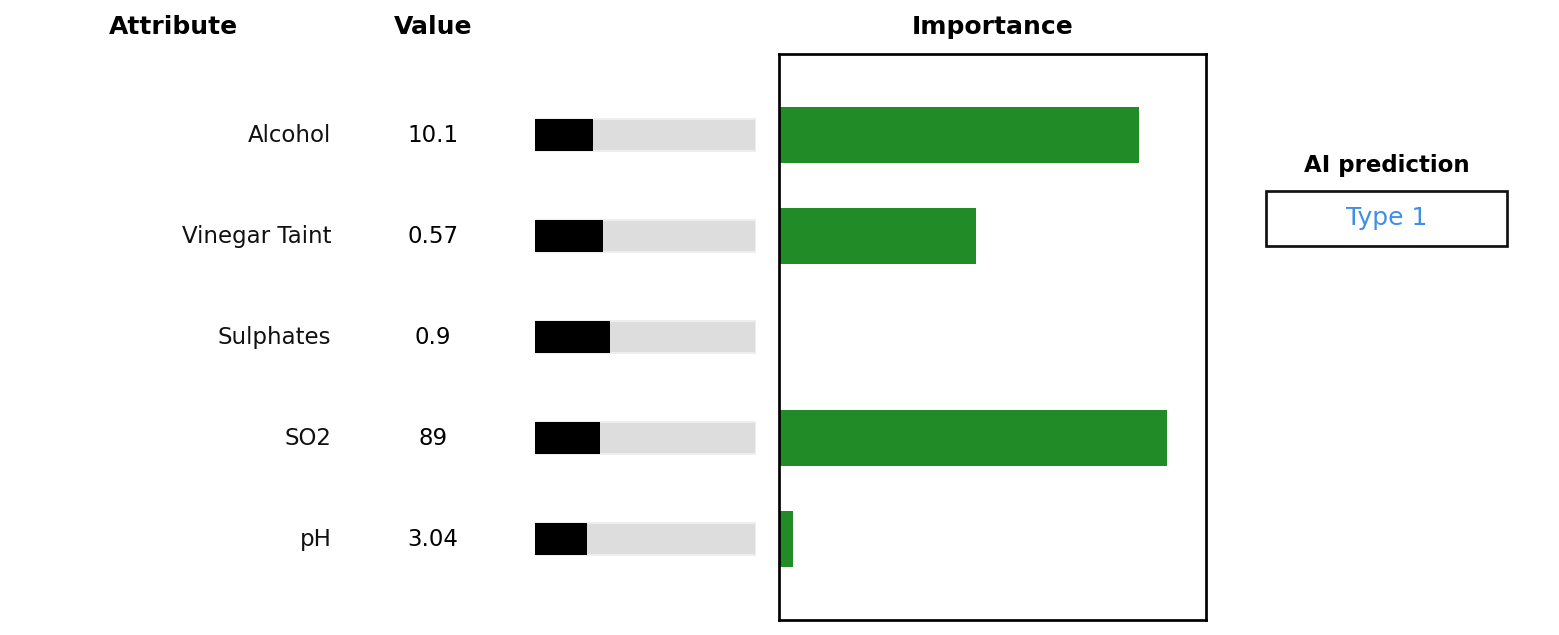

In [32]:
participant_trials = xaikitTest.preview_participant_trials(
    participant_id=1,
    visualization="importance",
    top_n=5,
    class_labels=["Type 1", "Type 2"],
    fallback="html",
)


## 9. Configure Cognitive Model

Choose the cognitive agent and parameter values used by simulation.


In [33]:
xaikitTest.guide_cognitive_models()


Cognitive model guide
Use the returned table to choose an agent and parameter ranges.
Typical call: `set_cognitive_model(cognitive_model_id='coax', cognitive_params={...})`.
Current design: `xai_method` = `shap`, `lime`, `lrp`, `none`.
Compatible cognitive agents: `coax`.
Note: `coax` supports attribution methods such as SHAP, LIME, LRP, IG, and DeepLift.


,CoAX,CoXAM,Sim2Real
Best for,Attribution-method forward simulation,Surrogate/strategy simulation for forward or c...,Feature-budget transfer tests
retrieval_threshold,"[-2.3, -1.5] memory strictness","[-2.8, -1.5] memory access",
exemplar_distance_sensitivity,"[1, 10] similarity sensitivity",,
attended_features,"[1, 5] attention span",,
feature_class_sensitivity,"[1, 7] attribution-to-class strength",,
opportunity_cost,,"[0, 10] accuracy-time tradeoff",
diffusion_noise,,"[0, 1] stochasticity",
counterfactual_margin,,"[0, 1] counterfactual threshold",
memory_budget,,,top_2_features or all_features


In [34]:
xaikitTest.set_cognitive_model(
    cognitive_model_id="coax",
    cognitive_params={
        "retrieval_threshold": -1.9,
        "exemplar_distance_sensitivity": 5,
        "attended_features": 3,
        "feature_class_sensitivity": 4,
    },
)

xaikitTest.cognitive_params


{'retrieval_threshold': -1.9,
 'exemplar_distance_sensitivity': 5,
 'attended_features': 3,
 'feature_class_sensitivity': 4}

## 10. Run Simulation

Run the cognitive model on one participant first, then save the latest result.


In [35]:
xaikitTest.validate(stage="execution", show=True)

simulated_results = xaikitTest.run_experiment(
    mode="participant_by_participant",
    participant_id=1,
)

simulated_results.head(10)


,participantId,trialId,block,trialWithinBlock,withinCondition,tested_w_xai,xai_method,dataId,instanceId,CV_age_group_levels,...,cog_param_retrieval_threshold,cog_param_exemplar_distance_sensitivity,cog_param_attended_features,cog_param_feature_class_sensitivity,forward_accuracy,prob_correct,pred_time,agent_prediction,ai_prediction,cognitive_correct_vs_ai
0,1,1,1,1,single_condition,False,shap,wine_quality,1329,young|adult|senior,...,-1.9,5,3,4,0.596125,0.596125,3.882503,True,0,False
1,1,2,1,2,single_condition,True,shap,wine_quality,535,young|adult|senior,...,-1.9,5,3,4,0.597268,0.597268,3.905366,True,0,False
2,1,3,1,3,single_condition,True,shap,wine_quality,1070,young|adult|senior,...,-1.9,5,3,4,0.599547,0.599547,3.950939,True,1,True
3,1,4,1,4,single_condition,False,shap,wine_quality,984,young|adult|senior,...,-1.9,5,3,4,0.594379,0.594379,3.847587,True,0,False
4,1,5,1,5,single_condition,False,shap,wine_quality,779,young|adult|senior,...,-1.9,5,3,4,0.592889,0.592889,3.817789,True,0,False
5,1,6,1,6,single_condition,False,shap,wine_quality,1210,young|adult|senior,...,-1.9,5,3,4,0.596799,0.596799,3.895976,True,0,False
6,1,7,1,7,single_condition,False,shap,wine_quality,1205,young|adult|senior,...,-1.9,5,3,4,0.592111,0.592111,3.802227,True,0,False
7,1,8,1,8,single_condition,True,shap,wine_quality,1130,young|adult|senior,...,-1.9,5,3,4,0.600947,0.600947,3.978943,True,0,False
8,1,9,1,9,single_condition,True,shap,wine_quality,1436,young|adult|senior,...,-1.9,5,3,4,0.585284,0.585284,3.665688,True,0,False
9,1,10,1,10,single_condition,True,shap,wine_quality,1413,young|adult|senior,...,-1.9,5,3,4,0.597995,0.597995,3.919908,True,0,False


In [36]:
sim_csv_path, sim_json_path = xaikitTest.save_results(
    out_dir="experiment_output",
)

print(f"Saved CSV : {sim_csv_path}")
print(f"Saved JSON: {sim_json_path}")


Saved CSV : experiment_output/simulated_results.csv
Saved JSON: experiment_output/simulated_results.json
